In [3]:
import os
import numpy as np
import numba as nb
from numba import cuda
import scipy
import matplotlib.pyplot as plt

# Log normalisation

In [ ]:
def open_mat_file(file_path, var_name):
    """Opens a .mat file and retrieves the specified variable."""
    mat_contents = scipy.io.loadmat(file_path)
    return mat_contents[var_name]

def apply_log_mapping(complex_data, c=1000.0):
    """Applies log mapping to complex SAR data.
    
    Log mapping formula: I = (log10(1 + c*A)) / (log10(1 + c))
    where A is min-max normalized amplitude, c controls brightness
    
    Args:
        complex_data: Complex array from .mat file
        c: Brightness control parameter (default 1000.0)
    
    Returns:
        log_mapped intensity in range [0., 1.]
    """
    # Get magnitude
    magnitude = np.abs(complex_data)
    
    # Min-max normalization to [0, 1]
    A = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
    
    # Apply log mapping formula
    I = np.log10(1 + c * A) / np.log10(1 + c)
    
    return I.astype(np.float32)


def process_single_mat_file(input_path, output_path, var_name="complex_img", c=1000.0):
    """Processes a single .mat file: loads, applies log mapping, saves as .npy.
    
    Args:
        input_path: Path to input .mat file
        output_path: Path to output .npy file
        var_name: Variable name in .mat file (default "complex_img")
        c: Brightness control parameter for log mapping (default 1000.0)
    """
    # Load the .mat file
    complex_data = open_mat_file(input_path, var_name)
    
    # Apply log mapping
    log_mapped_data = apply_log_mapping(complex_data, c)
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Save as .npy file
    np.save(output_path, log_mapped_data)
    print(f"Saved: {output_path}")


def process_directory_structure(input_root, output_root, var_name="complex_img", c=1000.0):
    """Recursively processes all .mat files in nested directory structure.
    
    Maintains the same folder hierarchy in output directory.
    
    Args:
        input_root: Root input directory (e.g., mat_files/)
        output_root: Root output directory (e.g., log_mapping/)
        var_name: Variable name in .mat files (default "complex_img")
        c: Brightness control parameter for log mapping (default 1000.0)
    """
    # Walk through the directory structure
    for root, dirs, files in os.walk(input_root):
        for file in files:
            if file.endswith('.mat'):
                # Get input file path
                input_file_path = os.path.join(root, file)
                
                # Create corresponding output path maintaining structure
                relative_path = os.path.relpath(root, input_root)
                output_dir = os.path.join(output_root, relative_path)
                
                # Change extension from .mat to .npy
                output_file_name = os.path.splitext(file)[0] + '.npy'
                output_file_path = os.path.join(output_dir, output_file_name)
                
                try:
                    process_single_mat_file(input_file_path, output_file_path, var_name, c)
                except Exception as e:
                    print(f"Error processing {input_file_path}: {e}")


# Define the input and output paths
INPUT_ROOT = "/workspace/alvin/SAR_ML/data/SAMPLE/mat_files"
OUTPUT_ROOT = "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping"

# Run the processing
# Uncomment the line below when ready to process all files
# process_directory_structure(INPUT_ROOT, OUTPUT_ROOT, var_name="complex_img", c=1000.0)

# GMM

In [24]:
from sklearn.mixture import GaussianMixture

def fit_gmm_components(intensity_image, n_components=3, n_bins=256):
    """
    Fit Gaussian Mixture Model to SAR intensity image.
    
    The 3 components typically represent:
    - C1: Clutter (low intensity)
    - C2: Speckle noise (medium intensity)  
    - T: Target scattering points (high intensity)
    
    Args:
        intensity_image: Log-mapped intensity image in range [0, 1]
        n_components: Number of Gaussian components (default 3)
        n_bins: Number of bins for histogram visualization (default 256)
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with GMM parameters and fitted model
    """
    # Flatten the intensity image for GMM fitting
    intensity_flat = intensity_image.flatten().reshape(-1, 1)
    
    # Fit GMM with 3 components
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',  # Full covariance matrices
        max_iter=100,
        # random_state=random_state,
        n_init=10  # Multiple initializations for stability
    )
    gmm.fit(intensity_flat)
    
    # Get parameters
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Sort by mean (ascending): C1 (clutter) < C2 (speckle) < T (target)
    sorted_idx = np.argsort(means)
    
    theta_C1 = {
        'mu': means[sorted_idx[0]], 
        'sigma': stds[sorted_idx[0]], 
        'pi': weights[sorted_idx[0]],
        'label': 'Clutter'
    }
    theta_C2 = {
        'mu': means[sorted_idx[1]], 
        'sigma': stds[sorted_idx[1]], 
        'pi': weights[sorted_idx[1]],
        'label': 'Speckle'
    }
    theta_T = {
        'mu': means[sorted_idx[2]], 
        'sigma': stds[sorted_idx[2]], 
        'pi': weights[sorted_idx[2]],
        'label': 'Target'
    }
    
    # Compute histogram for visualization
    histogram, bin_edges = np.histogram(intensity_flat, bins=n_bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return {
        'gmm': gmm,
        'components': [theta_C1, theta_C2, theta_T],
        'histogram': (histogram, bin_centers),
        'sorted_idx': sorted_idx
    }


def visualize_gmm_fit(intensity_image, gmm_result):
    """Visualize the GMM fit on intensity histogram."""
    histogram, bin_centers = gmm_result['histogram']
    components = gmm_result['components']
    
    plt.figure(figsize=(12, 6))
    
    # Plot histogram
    plt.bar(bin_centers, histogram, width=bin_centers[1]-bin_centers[0], 
            alpha=0.5, label='Intensity Histogram', color='gray')
    
    # Plot individual Gaussian components
    x = np.linspace(0, 1, 500)
    colors = ['blue', 'green', 'red']
    
    for i, (comp, color) in enumerate(zip(components, colors)):
        gaussian = comp['pi'] * (1/(comp['sigma']*np.sqrt(2*np.pi))) * \
                   np.exp(-0.5*((x - comp['mu'])/comp['sigma'])**2)
        plt.plot(x, gaussian, color=color, linewidth=2,
                label=f"{comp['label']}: μ={comp['mu']:.3f}, σ={comp['sigma']:.3f}, π={comp['pi']:.3f}")
    
    # Plot total GMM
    gmm = gmm_result['gmm']
    total_pdf = np.exp(gmm.score_samples(x.reshape(-1, 1)))
    plt.plot(x, total_pdf, 'k--', linewidth=2, label='GMM Total')
    
    plt.xlabel('Intensity')
    plt.ylabel('Density')
    plt.title('GMM Fit: SAR Intensity Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Example usage on a single image
# sample_img = apply_log_mapping(complex_img, c=1000.0)
# gmm_result = fit_gmm_components(sample_img)

# print("GMM Components:")
# for comp in gmm_result['components']:
#     print(f"{comp['label']:8s}: μ={comp['mu']:.4f}, σ={comp['sigma']:.4f}, π={comp['pi']:.4f}")

# # Visualize the fit
# visualize_gmm_fit(sample_img, gmm_result)

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [3]:
def npy_loader(path):
    """Load .npy file and convert to tensor"""
    image = np.load(path).astype(np.float32)
    
    image = torch.from_numpy(image)

    # Add channel dimension but keep as numpy
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)

    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image  # (H, W) -> (3, H, W)

synth_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/synth",
    extensions = (".npy"),
    loader = npy_loader,
)
meas_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/real",
    extensions = (".npy"),
    loader = npy_loader,
)

GMM Components:
Clutter : μ=0.2368, σ=0.0770, π=0.3305
Speckle : μ=0.3611, σ=0.0591, π=0.6143
Target  : μ=0.5195, σ=0.1569, π=0.0552


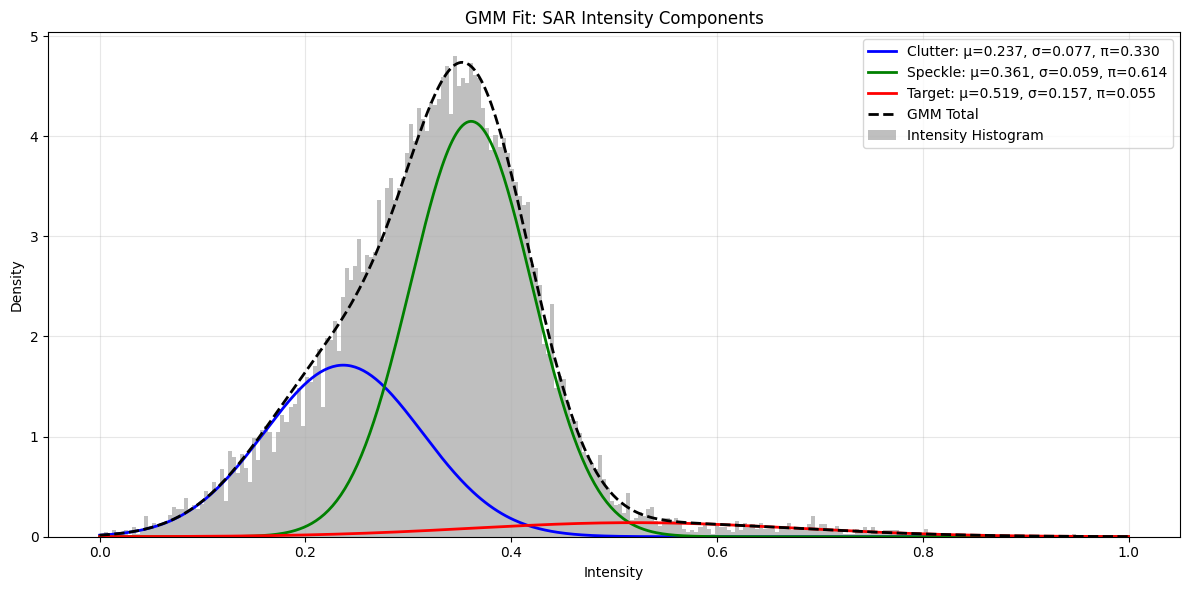

In [25]:
complex_img = np.load(synth_ds.samples[0][0])
gmm_result = fit_gmm_components(complex_img)

print("GMM Components:")
for comp in gmm_result['components']:
    print(f"{comp['label']:8s}: μ={comp['mu']:.4f}, σ={comp['sigma']:.4f}, π={comp['pi']:.4f}")

# Visualize the fit
visualize_gmm_fit(complex_img, gmm_result)